 # PART 2: WIND POWER

In [28]:
#Load data from csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns   
from scipy import stats 
from scipy.stats import binom, t as t_dist    

#To load the data
wind = pd.read_csv('wind_student.csv', parse_dates=['Datetime'])
wind = wind.sort_values('Datetime').reset_index(drop=True)

print(f"Total hours: {len(wind):,}")
print(f"Date range: {wind['Datetime'].min()} → {wind['Datetime'].max()}")
print(wind.describe())

Total hours: 26,280
Date range: 2013-01-01 00:00:00+00:00 → 2015-12-31 23:00:00+00:00
         Simulation       Actuals
count  26280.000000  26280.000000
mean       1.894674      1.587133
std        2.442843      1.991928
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.784415      0.671294
75%        2.837682      2.480148
max        8.051000      6.440800


In [ ]:
"""For Wind: we retain all hours including zero-generation hours, consistent with the definition of S_wind 
as the mean of Actuals over all hours. This is important because:
Wind can physically be zero at any time; zero-generation hours carry real forecast information"""

wind_all = wind.copy()
wind_all['error'] = wind_all['Actuals'] - wind_all['Simulation']
wind_all['year']  = wind_all['Datetime'].dt.year
wind_all['month'] = wind_all['Datetime'].dt.month
wind_all['hour']  = wind_all['Datetime'].dt.hour
wind_all['ym']    = wind_all['Datetime'].dt.to_period('M')
wind_all['date']  = wind_all['Datetime'].dt.date

# S_wind denominator: Actuals mean over all hours 2013-2015 (not just active hours)
# Consistent with: "Wind — mean(Actuals) over all hours, 2013-2015"
S_wind = wind_all['Actuals'].mean()
print(f"S_wind (global, all hours) = {S_wind:.4f}")

# Sensitivity check: S por año
for year in [2013, 2014, 2015]:
    s_yr = wind_all[wind_all['year'] == year]['Actuals'].mean()
    dev = (s_yr - S_wind) / S_wind * 100
    print(f"  S_{year} = {s_yr:.4f}  (deviation: {dev:+.1f}%)")

S_wind (global, all hours) = 1.5871
  S_2013 = 1.5646  (deviation: -1.4%)
  S_2014 = 1.5714  (deviation: -1.0%)
  S_2015 = 1.6254  (deviation: +2.4%)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_11472\3858833741.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  wind_all['ym']    = wind_all['Datetime'].dt.to_period('M')


In [31]:
# =========================
#  Metrics functions
# =========================
def compute_metrics(df, S, error_col='error'):
    """Calcula nMAE, nRMSE, MBE, EDF, Bias_share para un subset dado."""
    error = df[error_col]
    mae   = error.abs().mean()
    rmse  = np.sqrt((error ** 2).mean())
    mbe   = error.mean()
    mse   = (error ** 2).mean()
    return {
        'nMAE':       round(mae / S, 4),
        'nRMSE':      round(rmse / S, 4),
        'MBE':        round(mbe / S, 4),
        'EDF':        round(rmse / mae, 4),
        'Bias_share': round(mbe ** 2 / mse, 4)
    }

In [33]:
# =========================
#  PHASE A: Annual Overview
# =========================

"""Annual metrics over all hours (2013-2015)(wind retains also zero-generation hours)"""

rows = {}
for year in [2013, 2014, 2015]:
    subset = wind_all[wind_all['year'] == year]
    rows[str(year)] = compute_metrics(subset, S_wind)
rows['Full'] = compute_metrics(wind_all, S_wind)

phase_a_wind = pd.DataFrame(rows).T
print("Phase A: Wind Annual Overview")
print(phase_a_wind.to_string())

Phase A: Wind Annual Overview
        nMAE   nRMSE     MBE     EDF  Bias_share
2013  1.4237  1.9616 -0.3144  1.3778      0.0257
2014  1.3770  1.9505 -0.1116  1.4165      0.0033
2015  1.3980  1.9626 -0.1553  1.4039      0.0063
Full  1.3996  1.9582 -0.1938  1.3992      0.0098


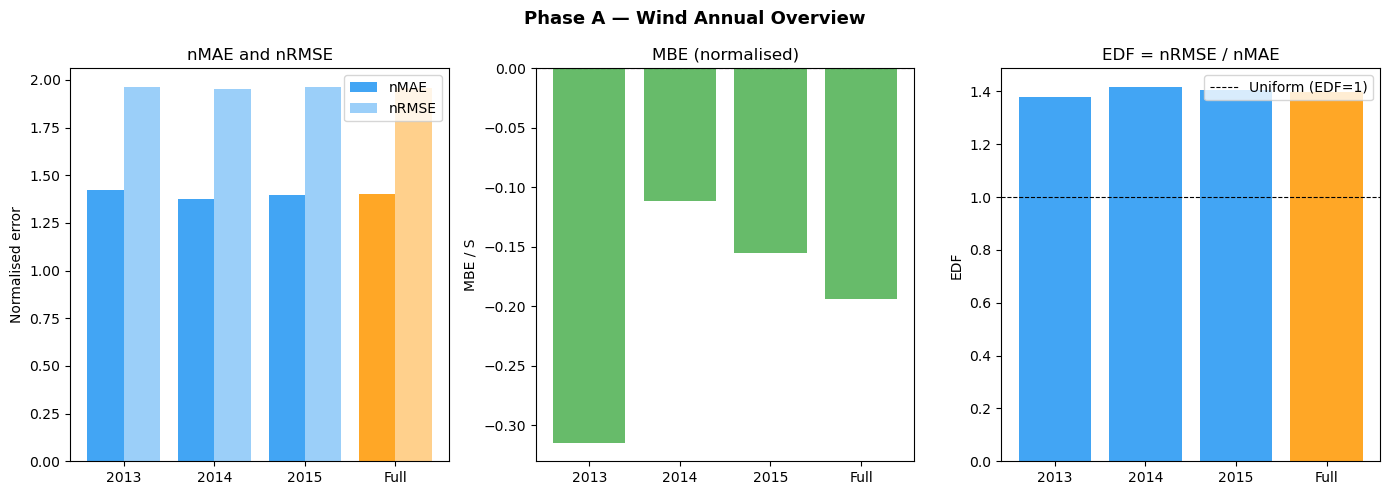

In [34]:
# METRICS PLOTS
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

years = ['2013', '2014', '2015', 'Full']
x = np.arange(len(years))
colors = ['#2196F3', '#2196F3', '#2196F3', '#FF9800']

# nMAE y nRMSE
axes[0].bar(x - 0.2, phase_a_wind['nMAE'],  0.4, label='nMAE',  color=colors, alpha=0.85)
axes[0].bar(x + 0.2, phase_a_wind['nRMSE'], 0.4, label='nRMSE', color=colors, alpha=0.45)
axes[0].set_title('nMAE and nRMSE')
axes[0].set_xticks(x); axes[0].set_xticklabels(years)
axes[0].legend(); axes[0].set_ylabel('Normalised error')

# MBE
bar_colors = ['#F44336' if v > 0 else '#4CAF50' for v in phase_a_wind['MBE']]
axes[1].bar(x, phase_a_wind['MBE'], color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('MBE (normalised)')
axes[1].set_xticks(x); axes[1].set_xticklabels(years)
axes[1].set_ylabel('MBE / S')

# EDF
axes[2].bar(x, phase_a_wind['EDF'], color=colors, alpha=0.85)
axes[2].axhline(1, color='black', linewidth=0.8, linestyle='--', label='Uniform (EDF=1)')
axes[2].set_title('EDF = nRMSE / nMAE')
axes[2].set_xticks(x); axes[2].set_xticklabels(years)
axes[2].set_ylabel('EDF'); axes[2].legend()

plt.suptitle('Phase A — Wind Annual Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_a_wind.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# =========================
#  PHASE B: MONTHLY AND CONDITIONAL STRUCTURE
# =========================

#B.1 Monthly structure climatology benchmark - Monthly error profiles (36 months)

monthly_rows = []
for ym, group in wind_all.groupby('ym'):
    m = compute_metrics(group, S_wind)
    m['period'] = ym
    monthly_rows.append(m)

monthly_wind = pd.DataFrame(monthly_rows).set_index('period').sort_index()
print("Phase B: Wind Monthly Error Profiles")
print(monthly_wind.to_string())


Phase B: Wind Monthly Error Profiles
           nMAE   nRMSE     MBE     EDF  Bias_share
period                                             
2013-01  1.4854  2.0170 -0.9896  1.3579      0.2407
2013-02  1.7508  2.3325 -0.0438  1.3322      0.0004
2013-03  1.3386  1.7638  0.3130  1.3177      0.0315
2013-04  1.4225  1.9867 -0.6735  1.3966      0.1149
2013-05  1.5142  2.0341 -0.7058  1.3434      0.1204
2013-06  1.0368  1.5373 -0.1643  1.4827      0.0114
2013-07  1.0751  1.5493  0.3010  1.4410      0.0377
2013-08  0.6835  1.0820  0.0394  1.5830      0.0013
2013-09  1.5254  2.0591 -0.8919  1.3499      0.1876
2013-10  1.7952  2.3210 -0.4862  1.2928      0.0439
2013-11  1.7560  2.2568 -0.1007  1.2852      0.0020
2013-12  1.7342  2.2312 -0.3626  1.2866      0.0264
2014-01  1.5433  2.0870 -0.2096  1.3523      0.0101
2014-02  2.2934  2.8049 -0.3252  1.2231      0.0134
2014-03  1.8462  2.2663  0.5853  1.2275      0.0667
2014-04  1.1083  1.6176 -0.0783  1.4595      0.0023
2014-05  1.5840  2.1826 -0.

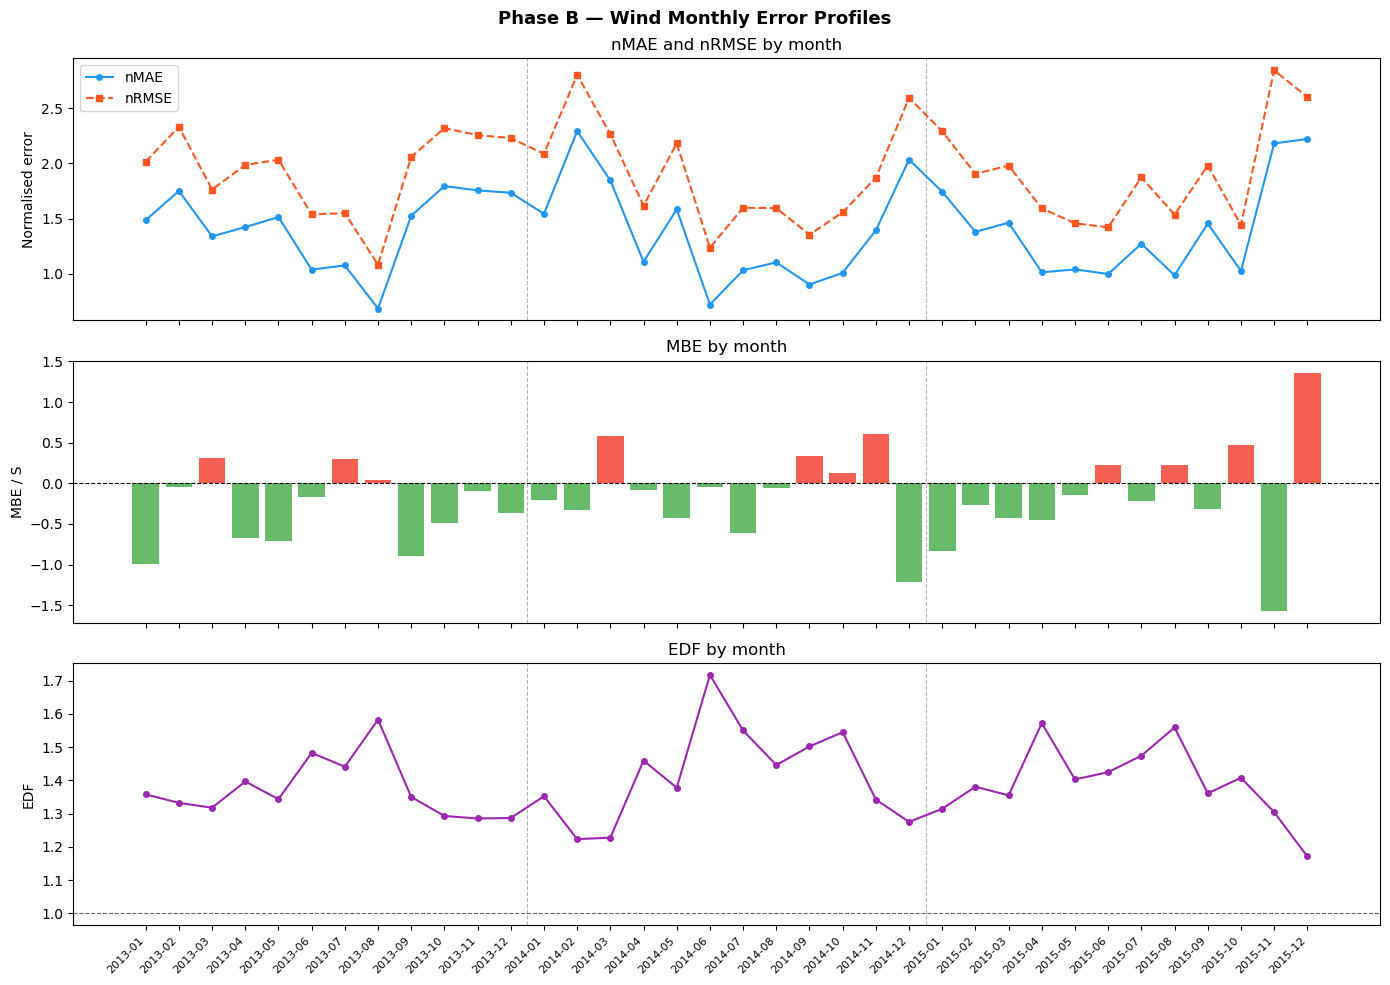

In [36]:
#B.1 PLOTS

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
x = np.arange(len(monthly_wind))
labels = [str(p) for p in monthly_wind.index]
year_breaks = [12, 24]

for ax in axes:
    for xb in year_breaks:
        ax.axvline(xb - 0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

axes[0].plot(x, monthly_wind['nMAE'],  marker='o', markersize=4, color='#2196F3', label='nMAE')
axes[0].plot(x, monthly_wind['nRMSE'], marker='s', markersize=4, color='#FF5722',
             linestyle='--', label='nRMSE')
axes[0].set_ylabel('Normalised error'); axes[0].legend()
axes[0].set_title('nMAE and nRMSE by month')

axes[1].bar(x, monthly_wind['MBE'],
            color=['#F44336' if v > 0 else '#4CAF50' for v in monthly_wind['MBE']], alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('MBE / S'); axes[1].set_title('MBE by month')

axes[2].plot(x, monthly_wind['EDF'], marker='o', markersize=4, color='#9C27B0')
axes[2].axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
axes[2].set_ylabel('EDF'); axes[2].set_title('EDF by month')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

plt.suptitle('Phase B — Wind Monthly Error Profiles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_b_wind_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
#B.2 Statistical tests on monthly error profiles

# Kruskal-Wallis and Brown-Forsythe over  monthly grouped errors (1-12)
monthly_abs    = [wind_all.loc[wind_all['month'] == m, 'error'].abs().values for m in range(1, 13)]
monthly_signed = [wind_all.loc[wind_all['month'] == m, 'error'].values         for m in range(1, 13)]

kw_abs_stat, kw_abs_p = stats.kruskal(*monthly_abs)
bf_abs_stat, bf_abs_p = stats.levene(*monthly_abs, center='median')

print("--- Primary: error magnitude ---")
print(f"Kruskal-Wallis:  H = {kw_abs_stat:.2f},  p = {kw_abs_p:.4e}")
print(f"Brown-Forsythe:  W = {bf_abs_stat:.2f},  p = {bf_abs_p:.4e}")

kw_sig_stat, kw_sig_p = stats.kruskal(*monthly_signed)
print("\n--- Supplementary: error direction ---")
print(f"Kruskal-Wallis:  H = {kw_sig_stat:.2f},  p = {kw_sig_p:.4e}")


--- Primary: error magnitude ---
Kruskal-Wallis:  H = 1467.18,  p = 3.8417e-308
Brown-Forsythe:  W = 102.73,  p = 2.1435e-230

--- Supplementary: error direction ---
Kruskal-Wallis:  H = 454.21,  p = 1.8276e-90


In [41]:
# =========================================================================
# B.3 Two-stage conditional analysis - Stage 1: Zero(the most fundamental) diagnostic
# =========================================================================

# Possible cases
mask_actuals_zero   = wind_all['Actuals'] == 0
mask_actuals_pos    = wind_all['Actuals'] > 0
mask_sim_zero       = wind_all['Simulation'] == 0
mask_sim_pos        = wind_all['Simulation'] > 0

n_total = len(wind_all)

# False calm rate: P(Simulation = 0 | Actuals > 0)
# The model predicts calm when in reality there is generation
n_actual_pos       = mask_actuals_pos.sum()
n_false_calm       = (mask_sim_zero & mask_actuals_pos).sum()
false_calm_rate    = n_false_calm / n_actual_pos

# False generation rate: P(Simulation > 0 | Actuals = 0)
# The model predicts generation when in reality there is none
n_actual_zero      = mask_actuals_zero.sum()
n_false_gen        = (mask_sim_pos & mask_actuals_zero).sum()
false_gen_rate     = n_false_gen / n_actual_zero

# Mean missed generation: mean(Actuals) where Simulation=0 and Actuals>0
mean_missed        = wind_all.loc[mask_sim_zero & mask_actuals_pos, 'Actuals'].mean()

# Mean phantom generation: mean(Simulation) where Simulation>0 and Actuals=0
mean_phantom       = wind_all.loc[mask_sim_pos & mask_actuals_zero, 'Simulation'].mean()

print("Phase B — Wind Stage 1: Zero/Nonzero Conditional Error Structure")
print("=" * 60)
print(f"\n  False calm rate   P(Sim=0 | Act>0)  : {false_calm_rate:.4f}  "
      f"({n_false_calm:,} / {n_actual_pos:,} hours)")
print(f"  False gen rate    P(Sim>0 | Act=0)  : {false_gen_rate:.4f}  "
      f"({n_false_gen:,} / {n_actual_zero:,} hours)")
print(f"  Mean missed gen   E[Act | Sim=0, Act>0] : {mean_missed:.4f} MW")
print(f"  Mean phantom gen  E[Sim | Sim>0, Act=0] : {mean_phantom:.4f} MW")

# Confusion Table 2x2  (framed as conditional error structure)
print("\n  Conditional Error Structure (2×2 table):")
print(f"  {'':30s} {'Sim = 0':>12} {'Sim > 0':>12} {'Total':>10}")
print(f"  {'Actuals > 0 (real generation)':30s} {n_false_calm:>12,} "
      f"{(mask_actuals_pos & mask_sim_pos).sum():>12,} {n_actual_pos:>10,}")
print(f"  {'Actuals = 0 (real calm)':30s} {(mask_actuals_zero & mask_sim_zero).sum():>12,} "
      f"{n_false_gen:>12,} {n_actual_zero:>10,}")
print(f"  {'Total':30s} {mask_sim_zero.sum():>12,} {mask_sim_pos.sum():>12,} {n_total:>10,}")

Phase B — Wind Stage 1: Zero/Nonzero Conditional Error Structure

  False calm rate   P(Sim=0 | Act>0)  : 0.3256  (5,729 / 17,597 hours)
  False gen rate    P(Sim>0 | Act=0)  : 0.6513  (5,655 / 8,683 hours)
  Mean missed gen   E[Act | Sim=0, Act>0] : 2.3207 MW
  Mean phantom gen  E[Sim | Sim>0, Act=0] : 2.8520 MW

  Conditional Error Structure (2×2 table):
                                      Sim = 0      Sim > 0      Total
  Actuals > 0 (real generation)         5,729       11,868     17,597
  Actuals = 0 (real calm)               3,028        5,655      8,683
  Total                                 8,757       17,523     26,280


In [44]:
# B.4 Conditional analysis — Stage 2: Continuous regime (nonzero hours only)

# =========================================================================
# Stage 2: Continuous regime analysis — only hours where Actuals>0 and Simulation>0
# =========================================================================

wind_nonzero = wind_all[(mask_actuals_pos) & (mask_sim_pos)].copy()

# Quantile thresholds over non-zero hours 2013-2015
q33 = wind_nonzero['Actuals'].quantile(0.33)
q67 = wind_nonzero['Actuals'].quantile(0.67)
print(f"Quantile thresholds (nonzero hours): Q33 = {q33:.4f}, Q67 = {q67:.4f}")

def assign_regime(val, q33, q67):
    if val < q33:   return 'Low'
    elif val < q67: return 'Mid'
    else:           return 'High'

wind_nonzero['regime'] = wind_nonzero['Actuals'].apply(assign_regime, args=(q33, q67))

regime_rows = {}
for regime in ['Low', 'Mid', 'High']:
    subset = wind_nonzero[wind_nonzero['regime'] == regime]
    regime_rows[regime] = compute_metrics(subset, S_wind)
    regime_rows[regime]['n_hours'] = len(subset)

regime_wind = pd.DataFrame(regime_rows).T
print("\nPhase B — Wind Stage 2: Conditional Analysis by Output Regime (nonzero hours)")
print(regime_wind.to_string())
print("\nNote: Output regime analysis is descriptive and diagnostic. Quantile thresholds")
print("are computed over the full evaluation sample to characterise model behaviour")
print("across the observed operating range. This does not constitute a predictive or")
print("out-of-sample claim; the thresholds serve as conditioning variables for")
print("structural diagnosis, not as forecasting rules.")

Quantile thresholds (nonzero hours): Q33 = 0.9406, Q67 = 2.9129

Phase B — Wind Stage 2: Conditional Analysis by Output Regime (nonzero hours)
        nMAE   nRMSE     MBE     EDF  Bias_share  n_hours
Low   1.4128  2.0390 -1.3575  1.4432      0.4433   3917.0
Mid   1.3243  1.7907 -0.7258  1.3521      0.1643   4034.0
High  1.8802  2.1266  1.2606  1.1310      0.3514   3917.0

Note: Output regime analysis is descriptive and diagnostic. Quantile thresholds
are computed over the full evaluation sample to characterise model behaviour
across the observed operating range. This does not constitute a predictive or
out-of-sample claim; the thresholds serve as conditioning variables for
structural diagnosis, not as forecasting rules.


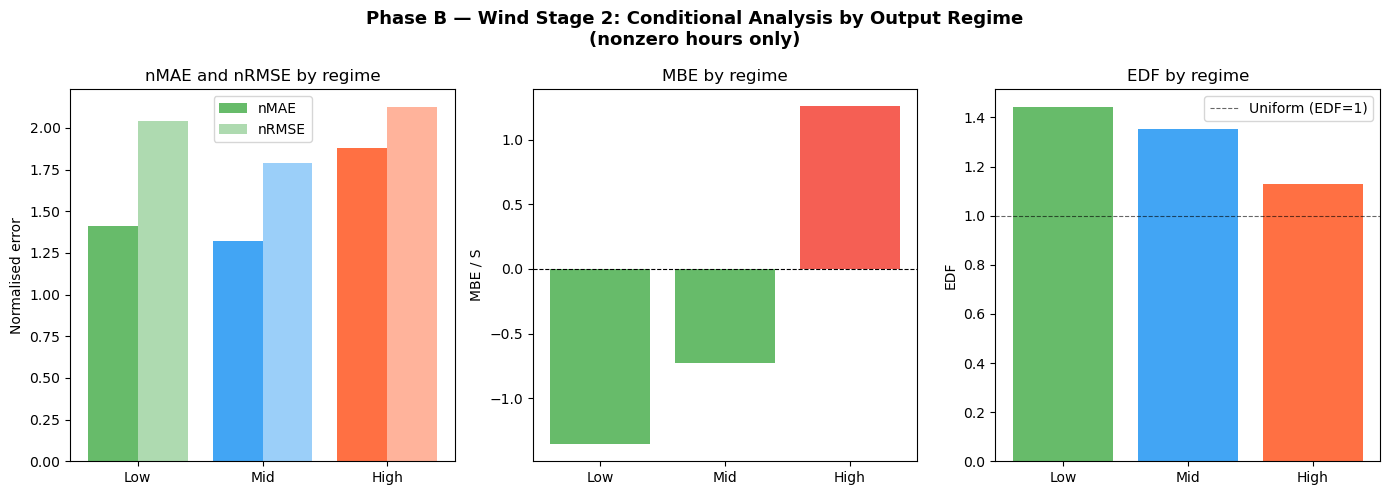

In [ ]:
# PHASE B - STAGE 2 PLOTS
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
regimes = ['Low', 'Mid', 'High']
x = np.arange(len(regimes))
colors = ['#4CAF50', '#2196F3', '#FF5722']

axes[0].bar(x - 0.2, regime_wind['nMAE'],  0.4, label='nMAE',  color=colors, alpha=0.85)
axes[0].bar(x + 0.2, regime_wind['nRMSE'], 0.4, label='nRMSE', color=colors, alpha=0.45)
axes[0].set_title('nMAE and nRMSE by regime')
axes[0].set_xticks(x); axes[0].set_xticklabels(regimes)
axes[0].set_ylabel('Normalised error'); axes[0].legend()

bar_colors = ['#F44336' if v > 0 else '#4CAF50' for v in regime_wind['MBE']]
axes[1].bar(x, regime_wind['MBE'], color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('MBE by regime')
axes[1].set_xticks(x); axes[1].set_xticklabels(regimes)
axes[1].set_ylabel('MBE / S')

axes[2].bar(x, regime_wind['EDF'], color=colors, alpha=0.85)
axes[2].axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.6, label='Uniform (EDF=1)')
axes[2].set_title('EDF by regime')
axes[2].set_xticks(x); axes[2].set_xticklabels(regimes)
axes[2].set_ylabel('EDF'); axes[2].legend()

plt.suptitle('Phase B — Wind Stage 2: Conditional Analysis by Output Regime\n(nonzero hours only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_b_wind_regime.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =========================================================================
# PHASE C - INTRADAY STRUCTURE AND TEMPORAL DEPENDENCE (suplementary analysis)
# =========================================================================

"""Methodology: "Wind — supplementary analysis. Same 24-hour mean error / MAE profile,
but with lower interpretive weight. Wind lacks a physically predictable intraday structure."""


hourly = wind_all.groupby('hour').agg(
    mean_error=('error', 'mean'),
    MAE=('error', lambda x: x.abs().mean()),
    n=('error', 'count')
).reset_index()

print("Phase C — Wind Hourly Error Profile (Supplementary)")
print(hourly.to_string())

# To identify the 2-3 worst hours by systematic absolute error
worst_hours_idx = hourly['mean_error'].abs().nlargest(3).index
worst_hours = hourly.loc[worst_hours_idx, 'hour'].tolist()
print(f"\nWorst hours by |mean_error|: {sorted(worst_hours)}")

Phase C — Wind Hourly Error Profile (Supplementary)
    hour  mean_error       MAE     n
0      0   -0.263314  2.127460  1095
1      1   -0.293557  2.087368  1095
2      2   -0.311024  2.124834  1095
3      3   -0.333661  2.143608  1095
4      4   -0.374417  2.127578  1095
5      5   -0.294766  2.101889  1095
6      6   -0.334382  2.105273  1095
7      7   -0.337266  2.164050  1095
8      8   -0.310344  2.210921  1095
9      9   -0.290035  2.311291  1095
10    10   -0.378339  2.381199  1095
11    11   -0.286928  2.371913  1095
12    12   -0.268601  2.417168  1095
13    13   -0.256414  2.392158  1095
14    14   -0.240410  2.399648  1095
15    15   -0.322648  2.364078  1095
16    16   -0.364307  2.316891  1095
17    17   -0.377394  2.259532  1095
18    18   -0.353022  2.118228  1095
19    19   -0.301461  2.165609  1095
20    20   -0.283456  2.151485  1095
21    21   -0.286494  2.144600  1095
22    22   -0.265079  2.157393  1095
23    23   -0.253653  2.166433  1095

Worst hours by |mean_e

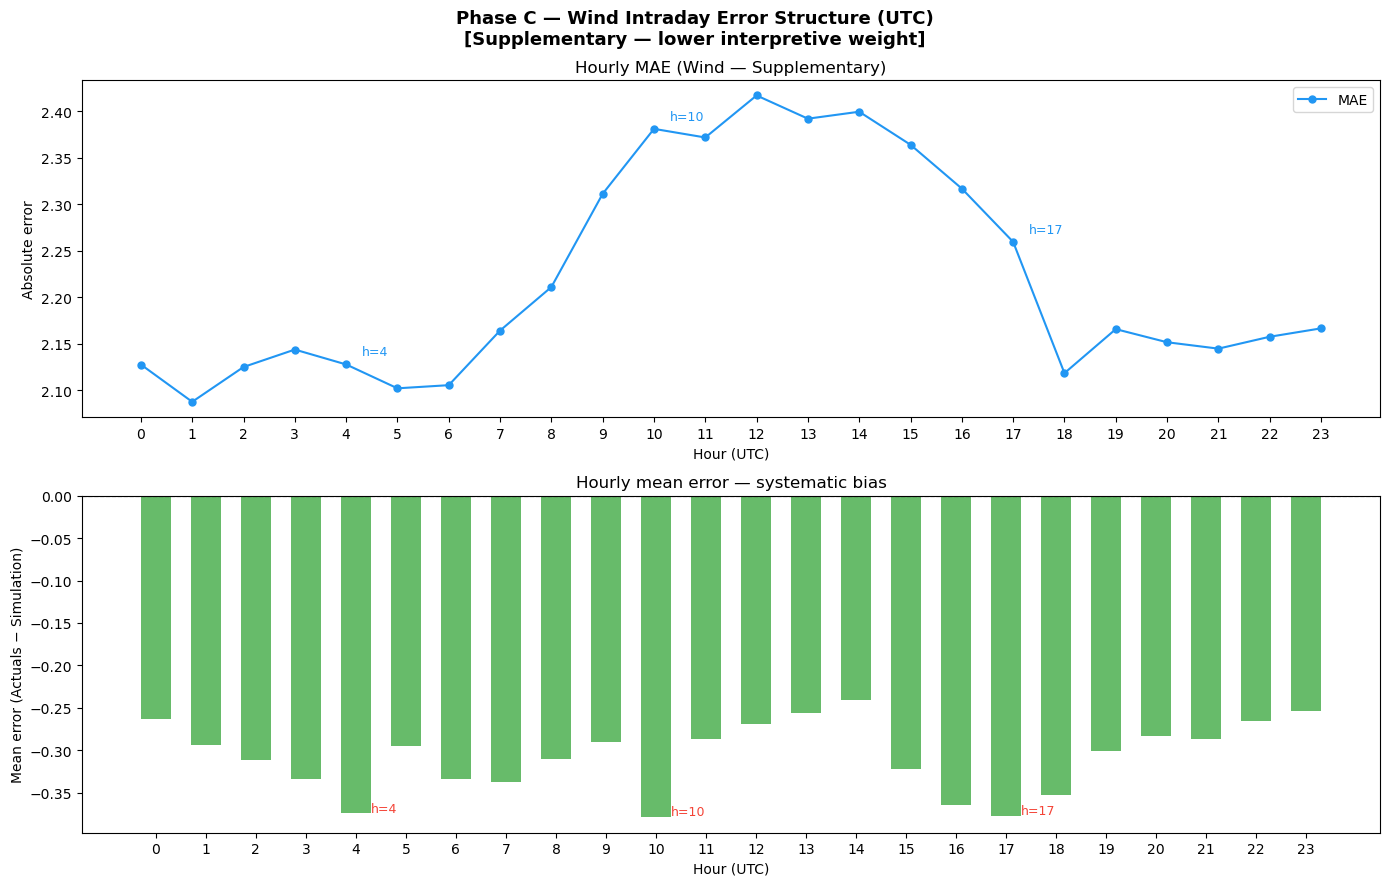

In [47]:
# PHASE C - PLOTS
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
x = hourly['hour']

# Panel 1: MAE per hour (primary focus for intraday structure)
axes[0].plot(x, hourly['MAE'], marker='o', markersize=5, color='#2196F3', label='MAE')
axes[0].set_title('Hourly MAE (Wind — Supplementary)')
axes[0].set_ylabel('Absolute error')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_xticks(x); axes[0].legend()

# To identify the 2-3 worst hours
for h in worst_hours:
    row = hourly[hourly['hour'] == h].iloc[0]
    axes[0].annotate(f'h={h}', xy=(h, row['MAE']),
                     xytext=(h + 0.3, row['MAE'] + 0.01), fontsize=9, color='#2196F3')

# Panel 2: mean error (systematic bias)
bar_colors = ['#F44336' if v > 0 else '#4CAF50' for v in hourly['mean_error']]
axes[1].bar(x, hourly['mean_error'], color=bar_colors, alpha=0.85, width=0.6)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Hourly mean error — systematic bias')
axes[1].set_ylabel('Mean error (Actuals − Simulation)')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_xticks(x)

for h in worst_hours:
    row = hourly[hourly['hour'] == h].iloc[0]
    axes[1].annotate(f'h={h}', xy=(h, row['mean_error']),
                     xytext=(h + 0.3, row['mean_error'] + 0.002), fontsize=9, color='#F44336')

plt.suptitle('Phase C — Wind Intraday Error Structure (UTC)\n[Supplementary — lower interpretive weight]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_c_wind.png', dpi=150, bbox_inches='tight')
plt.show()


In [48]:
# PHASE C.1 - BOOTSTRAP 95% CI FOR THE WORST HOURS (SUPPLEMENTARY)

np.random.seed(42)
B = 5000

# Pivot: errores diarios por hora
daily_pivot = wind_all.pivot_table(index='date', columns='hour', values='error', aggfunc='mean')

results_boot = {}
for h in sorted(worst_hours):
    daily_errors = daily_pivot[h].dropna().values
    n_days = len(daily_errors)
    boot_means = np.array([
        np.random.choice(daily_errors, size=n_days, replace=True).mean()
        for _ in range(B)
    ])
    ci_low  = np.percentile(boot_means, 2.5)
    ci_high = np.percentile(boot_means, 97.5)
    obs_mean = daily_errors.mean()
    results_boot[f'Hour {h}'] = {
        'n_days':        n_days,
        'mean_error':    round(obs_mean, 4),
        'CI_2.5%':       round(ci_low, 4),
        'CI_97.5%':      round(ci_high, 4),
        'excludes_zero': not (ci_low <= 0 <= ci_high)
    }

bootstrap_wind = pd.DataFrame(results_boot).T
print("Phase C — Bootstrap 95% CI for worst hours (B=5000)")
print(bootstrap_wind.to_string())

Phase C — Bootstrap 95% CI for worst hours (B=5000)
        n_days mean_error CI_2.5% CI_97.5% excludes_zero
Hour 4    1095    -0.3744 -0.5507  -0.2035          True
Hour 10   1095    -0.3783 -0.5713   -0.191          True
Hour 17   1095    -0.3774 -0.5673  -0.2005          True


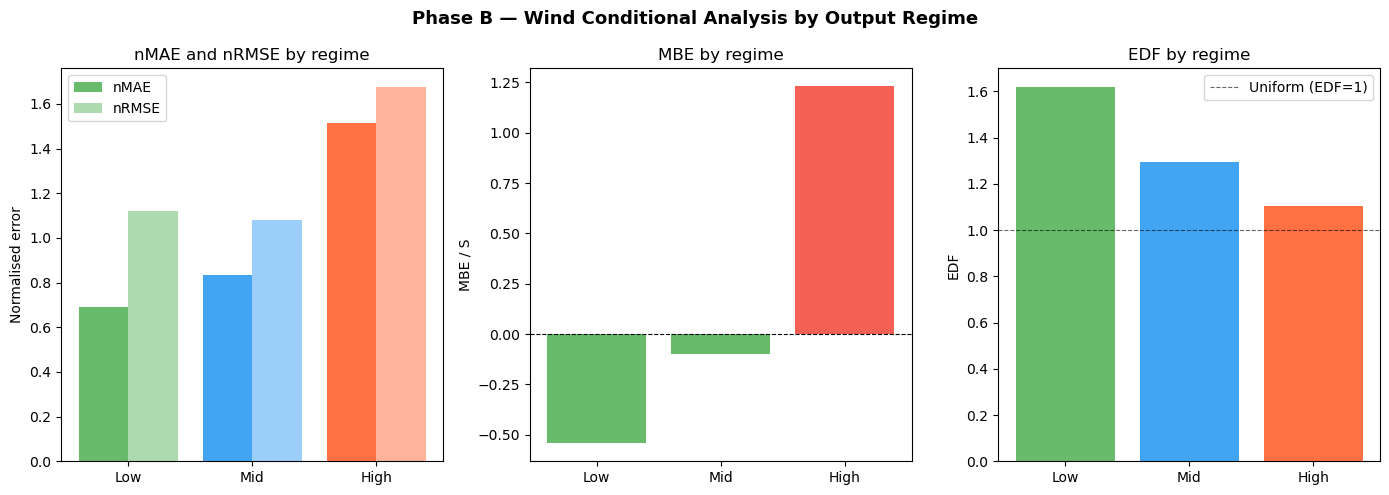

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

regimes = ['Low', 'Mid', 'High']
x = np.arange(len(regimes))
colors = ['#4CAF50', '#2196F3', '#FF5722']

# nMAE and nRMSE
axes[0].bar(x - 0.2, regime_wind['nMAE'],  0.4, label='nMAE',  color=colors, alpha=0.85)
axes[0].bar(x + 0.2, regime_wind['nRMSE'], 0.4, label='nRMSE', color=colors, alpha=0.45)
axes[0].set_title('nMAE and nRMSE by regime')
axes[0].set_xticks(x); axes[0].set_xticklabels(regimes)
axes[0].set_ylabel('Normalised error')
axes[0].legend()

# MBE
bar_colors = ['#F44336' if v > 0 else '#4CAF50' for v in regime_wind['MBE']]
axes[1].bar(x, regime_wind['MBE'], color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('MBE by regime')
axes[1].set_xticks(x); axes[1].set_xticklabels(regimes)
axes[1].set_ylabel('MBE / S')

# EDF
axes[2].bar(x, regime_wind['EDF'], color=colors, alpha=0.85)
axes[2].axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.6, label='Uniform (EDF=1)')
axes[2].set_title('EDF by regime')
axes[2].set_xticks(x); axes[2].set_xticklabels(regimes)
axes[2].set_ylabel('EDF')
axes[2].legend()

plt.suptitle('Phase B — Wind Conditional Analysis by Output Regime', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_b_wind_regime.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Compute mean error and MAE for each clock hour (0-23)
wind_active['hour'] = wind_active['Datetime'].dt.hour

hourly = wind_active.groupby('hour').agg(
    mean_error=('error', 'mean'),
    MAE=('error', lambda x: x.abs().mean()),
    n=('error', 'count')
).reset_index()

print("Phase C — Wind Hourly Error Profile")
print(hourly.to_string())

# gwMAE_h = sum(|error| * Actuals) / sum(Actuals) per hour
wind_active['abs_error'] = wind_active['error'].abs()
wind_active['weighted_error'] = wind_active['abs_error'] * wind_active['Actuals']

gwmae = wind_active.groupby('hour').apply(
    lambda g: g['weighted_error'].sum() / g['Actuals'].sum()
).reset_index()
gwmae.columns = ['hour', 'gwMAE']

hourly = hourly.merge(gwmae, on='hour')
print(hourly[['hour', 'MAE', 'gwMAE', 'mean_error']].to_string())

Phase C — Wind Hourly Error Profile
    hour  mean_error       MAE    n
0      0    0.453351  2.316309  737
1      1    0.424072  2.237478  738
2      2    0.465351  2.255365  730
3      3    0.439686  2.305316  722
4      4    0.325614  2.307736  729
5      5    0.389663  2.324740  729
6      6    0.520191  2.314788  684
7      7    0.515909  2.483082  667
8      8    0.534841  2.562080  672
9      9    0.596559  2.634501  685
10    10    0.458584  2.656660  704
11    11    0.537595  2.637730  719
12    12    0.553747  2.595758  747
13    13    0.521738  2.613167  746
14    14    0.526294  2.560345  766
15    15    0.505152  2.439994  759
16    16    0.359716  2.388458  778
17    17    0.276689  2.302711  799
18    18    0.298264  2.160897  786
19    19    0.395732  2.262136  768
20    20    0.391714  2.303269  759
21    21    0.476415  2.284272  737
22    22    0.528191  2.341730  722
23    23    0.538459  2.395006  714
    hour       MAE     gwMAE  mean_error
0      0  2.316309  3.0

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11472\1578757365.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gwmae = wind_active.groupby('hour').apply(


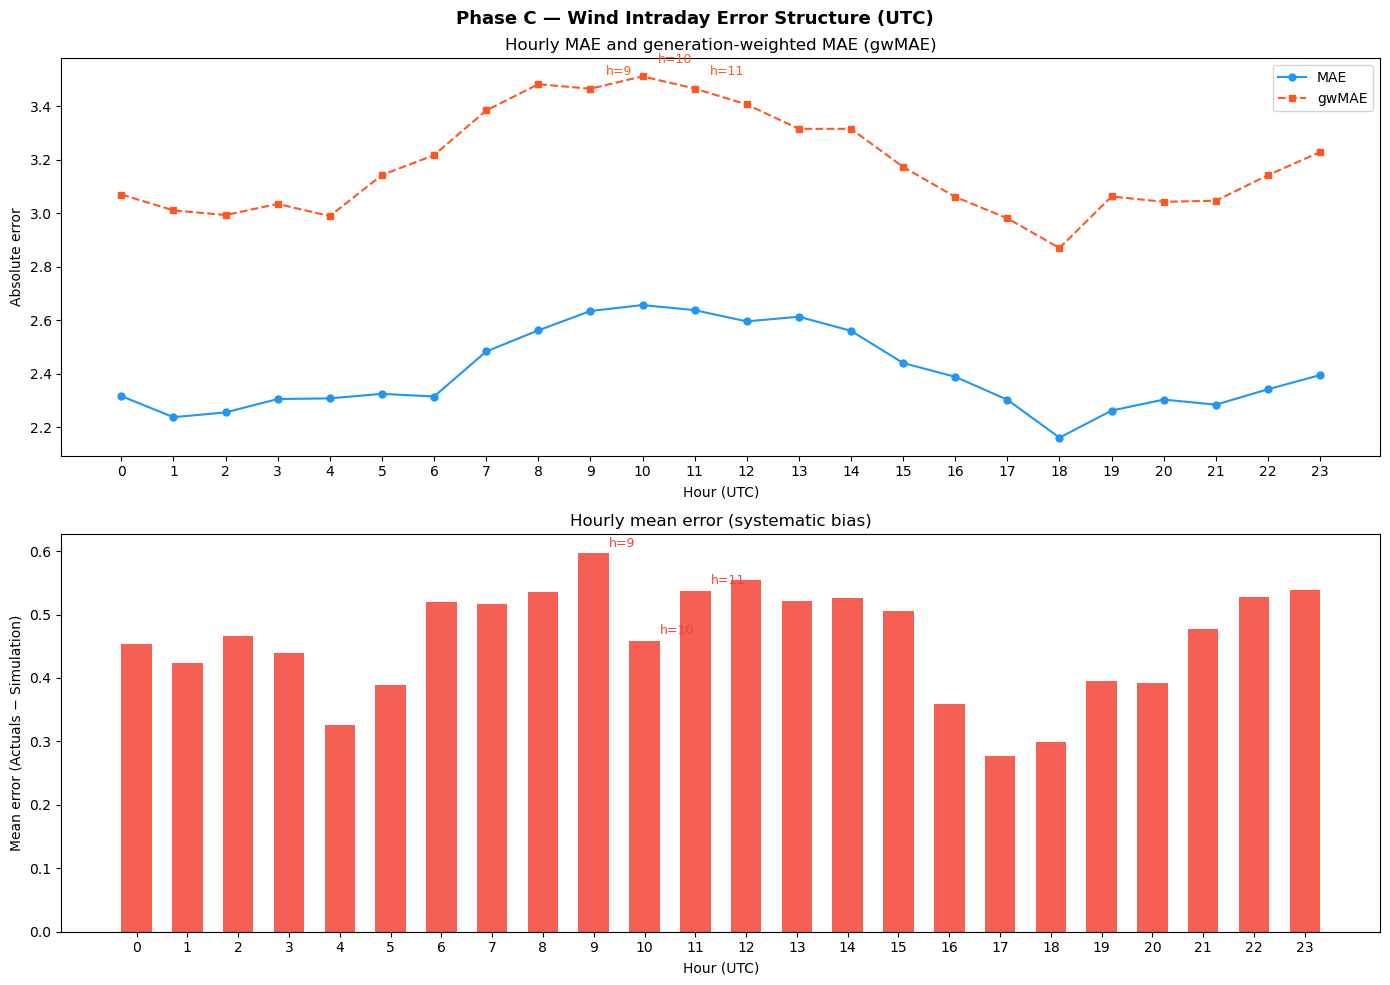

In [16]:
# Filter to meaningful solar hours only (n > 100)
hourly_plot = hourly[hourly['n'] > 100].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

x = hourly_plot['hour']

# Panel 1: MAE vs gwMAE
axes[0].plot(x, hourly_plot['MAE'],   marker='o', markersize=5, 
             color='#2196F3', label='MAE')
axes[0].plot(x, hourly_plot['gwMAE'], marker='s', markersize=5, 
             color='#FF5722', linestyle='--', label='gwMAE')
axes[0].set_title('Hourly MAE and generation-weighted MAE (gwMAE)')
axes[0].set_ylabel('Absolute error')
axes[0].set_xlabel('Hour (UTC)')
axes[0].legend()
axes[0].set_xticks(x)

# Annotate worst hours
for h in [10, 11, 9]:
    row = hourly_plot[hourly_plot['hour'] == h].iloc[0]
    axes[0].annotate(f'h={h}', xy=(h, row['gwMAE']),
                     xytext=(h + 0.3, row['gwMAE'] + 0.05),
                     fontsize=9, color='#FF5722')

# Panel 2: mean error (systematic bias)
bar_colors = ['#F44336' if v > 0 else '#4CAF50' 
              for v in hourly_plot['mean_error']]
axes[1].bar(x, hourly_plot['mean_error'], color=bar_colors, alpha=0.85, width=0.6)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Hourly mean error (systematic bias)')
axes[1].set_ylabel('Mean error (Actuals − Simulation)')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_xticks(x)

# Annotate worst hours
for h in [10, 11, 9]:
    row = hourly_plot[hourly_plot['hour'] == h].iloc[0]
    axes[1].annotate(f'h={h}', xy=(h, row['mean_error']),
                     xytext=(h + 0.3, row['mean_error'] + 0.01),
                     fontsize=9, color='#F44336')

plt.suptitle('Phase C — Wind Intraday Error Structure (UTC)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_c_wind.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
np.random.seed(42)
B = 5000
worst_hours = [10, 11, 12]

# Pivot to daily error matrix: rows = dates, columns = hours
wind_active['date'] = wind_active['Datetime'].dt.date
daily_pivot = wind_active.pivot_table(
    index='date', columns='hour', values='error', aggfunc='mean'
)

results = {}
for h in worst_hours:
    # Extract daily errors for this hour (drop NaN = days with no active obs)
    daily_errors = daily_pivot[h].dropna().values
    n_days = len(daily_errors)
    
    # Bootstrap: resample days with replacement (block = 1 day)
    boot_means = np.array([
        np.random.choice(daily_errors, size=n_days, replace=True).mean()
        for _ in range(B)
    ])
    
    ci_low  = np.percentile(boot_means, 2.5)
    ci_high = np.percentile(boot_means, 97.5)
    obs_mean = daily_errors.mean()
    excludes_zero = not (ci_low <= 0 <= ci_high)
    
    results[f'Hour {h}'] = {
        'n_days':       n_days,
        'mean_error':   round(obs_mean, 4),
        'CI_2.5%':      round(ci_low, 4),
        'CI_97.5%':     round(ci_high, 4),
        'excludes_zero': excludes_zero
    }

bootstrap_wind = pd.DataFrame(results).T
print("Phase C — Bootstrap 95% CI for worst hours (B=5000)")
print(bootstrap_wind.to_string())


Phase C — Bootstrap 95% CI for worst hours (B=5000)
        n_days mean_error CI_2.5% CI_97.5% excludes_zero
Hour 10    704     0.4586   0.213   0.7066          True
Hour 11    719     0.5376  0.2884    0.771          True
Hour 12    747     0.5537  0.3246   0.7959          True


In [18]:

# =============================================================================
# Phase D — Primary Benchmark Construction (PV)
# Benchmark type : month x hour climatology
# Training period: 2013 active hours only (Actuals > 0)
# Application    : out-of-sample 2014-2015
# Logic          : for each (month, hour) cell, compute mean Actuals in 2013
#                  this serves as the benchmark forecast for all matching
#                  observations in 2014-2015
# =============================================================================
wind_2013 = wind_active[wind_active['Datetime'].dt.year == 2013].copy()

climatology_primary = (
    wind_2013.groupby(['month', 'hour'])['Actuals']
    .mean()
    .reset_index()
    .rename(columns={'Actuals': 'bench_primary'})
)

print(f"Primary benchmark cells: {len(climatology_primary)}")
print(climatology_primary.head(10).to_string())
print()
print(climatology_primary['month'].unique())
print(climatology_primary.groupby('month').size())




Primary benchmark cells: 288
   month  hour  bench_primary
0      1     0       2.073094
1      1     1       2.135349
2      1     2       2.172494
3      1     3       2.197216
4      1     4       1.845726
5      1     5       1.578648
6      1     6       1.685293
7      1     7       1.761818
8      1     8       1.988872
9      1     9       2.293750

[ 1  2  3  4  5  6  7  8  9 10 11 12]
month
1     24
2     24
3     24
4     24
5     24
6     24
7     24
8     24
9     24
10    24
11    24
12    24
dtype: int64


Unmatched observations: 0

T = 24 monthly observations
         ym  MAE_model  MAE_bench    n   delta_l  model_wins
0   2014-01   2.900388   1.859496  476  1.040892       False
1   2014-02   3.725506   2.069301  484  1.656205       False
2   2014-03   3.186220   1.963513  602  1.222707       False
3   2014-04   1.866486   1.296481  482  0.570006       False
4   2014-05   2.614586   1.547987  497  1.066599       False
5   2014-06   1.311540   1.321538  352 -0.009997        True
6   2014-07   1.533523   1.542231  393 -0.008708        True
7   2014-08   1.895896   1.784680  495  0.111216       False
8   2014-09   1.976170   1.462656  431  0.513514       False
9   2014-10   1.910792   1.396986  475  0.513806       False
10  2014-11   2.439502   2.046034  577  0.393468       False
11  2014-12   3.159447   1.967948  505  1.191499       False
12  2015-01   2.726842   1.800164  566  0.926678       False
13  2015-02   2.385843   1.985633  424  0.400210       False
14  2015-03   2.270768   1.938

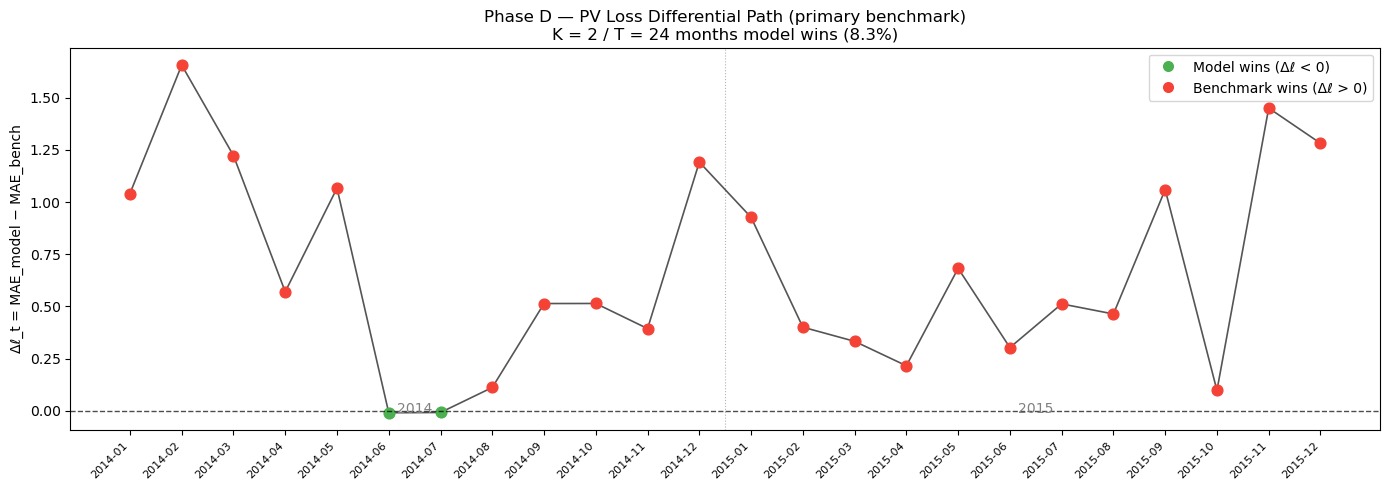

In [19]:
# =============================================================================
# Loss Differential Series (PV, primary benchmark)
# Out-of-sample period: 2014-2015 active hours
# For each month t: delta_l_t = MAE_model_t - MAE_bench_t
# Negative delta_l_t means model beats benchmark in month t
# =============================================================================

# Restrict to out-of-sample active hours
wind_oos = wind_active[wind_active['Datetime'].dt.year.isin([2014, 2015])].copy()

# Merge benchmark forecasts
wind_oos = wind_oos.merge(climatology_primary, on=['month', 'hour'], how='left')

# Check for unmatched cells
n_missing = wind_oos['bench_primary'].isna().sum()
print(f"Unmatched observations: {n_missing}")

# Compute monthly MAE for model and benchmark
wind_oos['ae_model'] = (wind_oos['Actuals'] - wind_oos['Simulation']).abs()
wind_oos['ae_bench'] = (wind_oos['Actuals'] - wind_oos['bench_primary']).abs()

monthly_loss = wind_oos.groupby('ym').agg(
    MAE_model=('ae_model', 'mean'),
    MAE_bench=('ae_bench', 'mean'),
    n=('ae_model', 'count')
).reset_index()

monthly_loss['delta_l'] = monthly_loss['MAE_model'] - monthly_loss['MAE_bench']
monthly_loss['model_wins'] = monthly_loss['delta_l'] < 0

print(f"\nT = {len(monthly_loss)} monthly observations")
print(monthly_loss.to_string())

# =============================================================================
# plot the loss differential path
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(monthly_loss))
labels = [str(p) for p in monthly_loss['ym']]
colors = ['#4CAF50' if v < 0 else '#F44336' for v in monthly_loss['delta_l']]

# Line
ax.plot(x, monthly_loss['delta_l'], color='#555555', linewidth=1.2, zorder=1)

# Dots coloured by win/loss
for i, (xi, yi, c) in enumerate(zip(x, monthly_loss['delta_l'], colors)):
    ax.scatter(xi, yi, color=c, s=60, zorder=2)

# Reference line and year separator
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(11.5, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(5.5,  monthly_loss['delta_l'].min() * 0.92, '2014', ha='center', fontsize=10, color='grey')
ax.text(17.5, monthly_loss['delta_l'].min() * 0.92, '2015', ha='center', fontsize=10, color='grey')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Δℓ_t = MAE_model − MAE_bench')
ax.set_title(
    f'Phase D — PV Loss Differential Path (primary benchmark)\n'
    f'K = 2 / T = 24 months model wins ({2/24*100:.1f}%)',
    fontsize=12
)
ax.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#4CAF50', 
               markersize=9, label='Model wins (Δℓ < 0)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#F44336', 
               markersize=9, label='Benchmark wins (Δℓ > 0)')
], loc='upper right')

plt.tight_layout()
plt.savefig('phase_d_pv_loss_path.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:

# =============================================================================
# Sign Test + HLN-corrected Diebold-Mariano Test (PV)
# H0: model and benchmark equally likely to win (p = 0.5)
# H1: model wins more often than chance (p > 0.5)
# =============================================================================

delta_l = monthly_loss['delta_l'].values
T = len(delta_l)
K = (delta_l < 0).sum()

# --- Sign test ---
# One-sided exact binomial p-value (H1: p > 0.5)
sign_p = binom.sf(K - 1, T, 0.5)
print(f"Sign test:  K = {K} / T = {T}  ({K/T*100:.1f}%),  p = {sign_p:.4f}")

# --- HLN-corrected DM test ---
delta_bar = delta_l.mean()

# Newey-West HAC standard error, bandwidth = floor(T^(1/3))
bw = int(np.floor(T ** (1/3)))
print(f"\nHAC bandwidth: {bw}")

n = T
gamma0 = np.var(delta_l, ddof=0)
hac_var = gamma0
for lag in range(1, bw + 1):
    gamma_lag = np.mean(
        (delta_l[lag:] - delta_bar) * (delta_l[:-lag] - delta_bar)
    )
    hac_var += 2 * (1 - lag / (bw + 1)) * gamma_lag

se_hac = np.sqrt(hac_var / T)

# HLN small-sample correction (h=1)
h = 1
dm_raw  = delta_bar / se_hac
hln_correction = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
dm_star = dm_raw * hln_correction

# One-sided p-value: H1: E[delta_l] < 0 (model better)
p_dm = t_dist.cdf(dm_star, df=T-1)
print(f"\nDM test (HLN-corrected):")
print(f"  delta_bar = {delta_bar:.4f}")
print(f"  SE_HAC    = {se_hac:.4f}")
print(f"  DM*       = {dm_star:.4f}")
print(f"  p-value   = {p_dm:.4f}  (one-sided, H1: model better)")

Sign test:  K = 2 / T = 24  (8.3%),  p = 1.0000

HAC bandwidth: 2

DM test (HLN-corrected):
  delta_bar = 0.6660
  SE_HAC    = 0.1176
  DM*       = 5.5444
  p-value   = 1.0000  (one-sided, H1: model better)


In [ ]:
# =============================================================================
# Giacomini-Rossi Fluctuation Test (PV, primary benchmark)
# GR(t,m) = sqrt(m) * mu_hat(t,m) / sqrt(f_hat)
# where f_hat = full-sample Newey-West HAC variance
# Critical values (GR 2010, Table 1, m=6): 2.55 (5%), 3.394 (1%)
# =============================================================================

def gr_test(delta_l, m):
    T = len(delta_l)
    delta_bar = delta_l.mean()

    # Full-sample Newey-West HAC variance
    bw = int(np.floor(T ** (1/3)))
    gamma0 = np.var(delta_l, ddof=0)
    hac_var = gamma0
    for lag in range(1, bw + 1):
        gamma_lag = np.mean(
            (delta_l[lag:] - delta_bar) * (delta_l[:-lag] - delta_bar)
        )
        hac_var += 2 * (1 - lag / (bw + 1)) * gamma_lag

    # Rolling GR statistics
    gr_stats = []
    for t in range(m - 1, T):
        window = delta_l[t - m + 1 : t + 1]
        mu_hat = window.mean()
        se_mu  = np.sqrt(hac_var / m)   # = sqrt(f_hat / m)
        gr     = mu_hat / se_mu          # = sqrt(m) * mu_hat / sqrt(f_hat)
        gr_stats.append({'t': t, 'gr': gr, 'mu_hat': mu_hat})

    return pd.DataFrame(gr_stats)

delta_l = monthly_loss['delta_l'].values

# Primary window m=6, robustness m in {4, 8}
results_gr = {}
for m in [4, 6, 8]:
    gr_df = gr_test(delta_l, m)
    sup_gr = gr_df['gr'].abs().max()
    results_gr[f'm={m}'] = {
        'sup|GR|':   round(sup_gr, 4),
        'cv_5%':     2.55,
        'cv_1%':     3.394,
        'reject_5%': sup_gr > 2.55,
        'reject_1%': sup_gr > 3.394
    }

gr_summary = pd.DataFrame(results_gr).T
print("GR Fluctuation Test — Wind (primary benchmark)")
print(gr_summary.to_string())


GR Fluctuation Test — PV (primary benchmark)
    sup|GR| cv_5%  cv_1% reject_5% reject_1%
m=4  3.9191  2.55  3.394      True      True
m=6  3.9305  2.55  3.394      True      True
m=8  3.5893  2.55  3.394      True      True


In [24]:
# =============================================================================
# Phase D — Secondary Benchmark Construction (PV)
# Benchmark type : ISO week x hour climatology
# Training period: 2013 active hours only (Actuals > 0)
# ISO year filter: enforced to avoid year-end boundary contamination
# Application    : out-of-sample 2014-2015
# =============================================================================

wind_2013 = wind_active[wind_active['Datetime'].dt.year == 2013].copy()

iso = wind_2013['Datetime'].dt.isocalendar()
wind_2013['iso_year'] = iso.year.astype(int)
wind_2013['isoweek']  = iso.week.astype(int)
wind_2013['hour']     = wind_2013['Datetime'].dt.hour

# Enforce ISO year = 2013 to avoid boundary contamination
wind_2013 = wind_2013[wind_2013['iso_year'] == 2013].copy()

climatology_secondary = (
    wind_2013.groupby(['isoweek', 'hour'])['Actuals']
    .mean()
    .reset_index()
    .rename(columns={'Actuals': 'bench_secondary'})
)

cell_counts = (
    wind_2013.groupby(['isoweek', 'hour'])
        .size()
        .reset_index(name='n_obs')
)

print(f"Secondary benchmark cells: {len(climatology_secondary)}")
print(f"Min obs per cell: {cell_counts['n_obs'].min()}")
print(f"Max obs per cell: {cell_counts['n_obs'].max()}")
print(f"Mean obs per cell: {cell_counts['n_obs'].mean():.1f}")


Secondary benchmark cells: 1246
Min obs per cell: 1
Max obs per cell: 7
Mean obs per cell: 4.7


In [49]:
# =============================================================================
# PHASE D —RELATIVE BENCHMARK STABILITY ANALYSIS (WIND)
# PHASE D.1 - Primary benchmark: month climatology
# =============================================================================

"""Trained in 2013, applied out-of-sample to 2014-2015. 
Methodology: "Wind — month climatology: (month) → mean(Actuals), ~720h/cell" """


wind_2013 = wind_all[wind_all['year'] == 2013].copy()

climatology_primary = (
    wind_2013.groupby('month')['Actuals']
    .mean()
    .reset_index()
    .rename(columns={'Actuals': 'bench_primary'})
)

print("Primary benchmark cells (month only):")
print(climatology_primary.to_string())
print(f"\nObs per cell (approx): {len(wind_2013) / 12:.0f} hours")

Primary benchmark cells (month only):
    month  bench_primary
0       1       1.273665
1       2       2.345064
2       3       2.555555
3       4       1.132686
4       5       1.248555
5       6       1.115273
6       7       1.681190
7       8       0.790191
8       9       0.963454
9      10       1.522114
10     11       2.331464
11     12       1.868254

Obs per cell (approx): 730 hours


In [50]:
# =============================================================================
# Phase D.2 — Loss Differential series - Primary benchmark
# =============================================================================

# Out-of-sample: 2014-2015
wind_oos = wind_all[wind_all['year'].isin([2014, 2015])].copy()
wind_oos = wind_oos.merge(climatology_primary, on='month', how='left')

wind_oos['ae_model'] = (wind_oos['Actuals'] - wind_oos['Simulation']).abs()
wind_oos['ae_bench'] = (wind_oos['Actuals'] - wind_oos['bench_primary']).abs()

monthly_loss = wind_oos.groupby('ym').agg(
    MAE_model=('ae_model', 'mean'),
    MAE_bench=('ae_bench', 'mean'),
    n=('ae_model', 'count')
).reset_index()

monthly_loss['delta_l']    = monthly_loss['MAE_model'] - monthly_loss['MAE_bench']
monthly_loss['model_wins'] = monthly_loss['delta_l'] < 0

K_primary = monthly_loss['model_wins'].sum()
T = len(monthly_loss)
print(f"T = {T} monthly observations, K = {K_primary} months model wins ({K_primary/T*100:.1f}%)")
print(monthly_loss.to_string())

T = 24 monthly observations, K = 1 months model wins (4.2%)
         ym  MAE_model  MAE_bench    n   delta_l  model_wins
0   2014-01   2.449404   1.700006  744  0.749398       False
1   2014-02   3.639904   2.135340  672  1.504565       False
2   2014-03   2.930224   2.153871  744  0.776354       False
3   2014-04   1.758966   1.138198  720  0.620767       False
4   2014-05   2.513977   1.366623  744  1.147355       False
5   2014-06   1.142025   1.115521  720  0.026503       False
6   2014-07   1.636638   1.337373  744  0.299265       False
7   2014-08   1.750132   1.575791  744  0.174342       False
8   2014-09   1.430972   1.271666  720  0.159307       False
9   2014-10   1.599843   1.374768  744  0.225075       False
10  2014-11   2.212798   1.965705  720  0.247094       False
11  2014-12   3.230091   1.888325  744  1.341766       False
12  2015-01   2.767726   1.812896  744  0.954830       False
13  2015-02   2.190162   1.959615  672  0.230547       False
14  2015-03   2.321119   

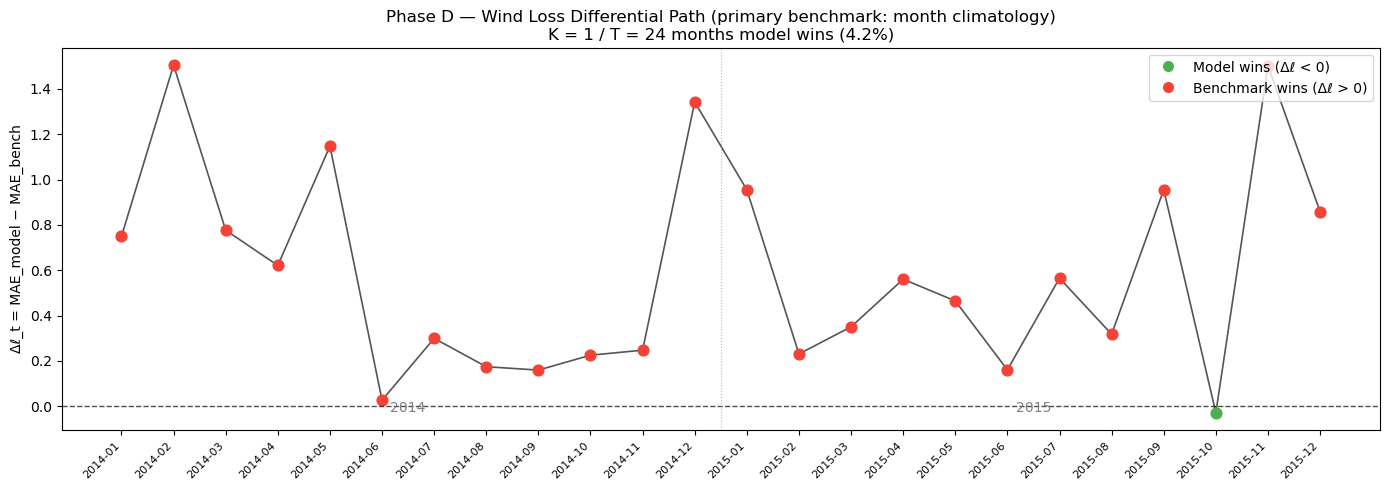

In [51]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(T)
labels = [str(p) for p in monthly_loss['ym']]
colors = ['#4CAF50' if v < 0 else '#F44336' for v in monthly_loss['delta_l']]

ax.plot(x, monthly_loss['delta_l'], color='#555555', linewidth=1.2, zorder=1)
for xi, yi, c in zip(x, monthly_loss['delta_l'], colors):
    ax.scatter(xi, yi, color=c, s=60, zorder=2)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(11.5, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(5.5,  monthly_loss['delta_l'].min() * 0.92, '2014', ha='center', fontsize=10, color='grey')
ax.text(17.5, monthly_loss['delta_l'].min() * 0.92, '2015', ha='center', fontsize=10, color='grey')

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Δℓ_t = MAE_model − MAE_bench')
ax.set_title(
    f'Phase D — Wind Loss Differential Path (primary benchmark: month climatology)\n'
    f'K = {K_primary} / T = {T} months model wins ({K_primary/T*100:.1f}%)',
    fontsize=12
)
ax.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#4CAF50',
               markersize=9, label='Model wins (Δℓ < 0)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#F44336',
               markersize=9, label='Benchmark wins (Δℓ > 0)')
], loc='upper right')
plt.tight_layout()
plt.savefig('phase_d_wind_loss_primary.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# =============================================================================
# Phase D.3 — Sign Test + HLN-DM Test - Primary Benchmark
# =============================================================================

def hln_dm_test(delta_l):
    """HLN-corrected Diebold-Mariano test. H1: E[delta_l] < 0 (model better)."""
    T = len(delta_l)
    delta_bar = delta_l.mean()
    bw = int(np.floor(T ** (1/3)))
    gamma0 = np.var(delta_l, ddof=0)
    hac_var = gamma0
    for lag in range(1, bw + 1):
        gamma_lag = np.mean((delta_l[lag:] - delta_bar) * (delta_l[:-lag] - delta_bar))
        hac_var += 2 * (1 - lag / (bw + 1)) * gamma_lag
    se_hac = np.sqrt(hac_var / T)
    h = 1
    dm_raw = delta_bar / se_hac
    hln_correction = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    dm_star = dm_raw * hln_correction
    p_dm = t_dist.cdf(dm_star, df=T-1)
    return dict(delta_bar=round(delta_bar,4), bw=bw, SE_HAC=round(se_hac,4),
                DM_star=round(dm_star,4), p_value=round(p_dm,4))

delta_l = monthly_loss['delta_l'].values

# Sign test
sign_p = binom.sf(K_primary - 1, T, 0.5)
print(f"Sign test: K = {K_primary} / T = {T}  ({K_primary/T*100:.1f}%),  p = {sign_p:.4f}")

# HLN-DM
dm_res = hln_dm_test(delta_l)
print(f"\nDM test (HLN-corrected):")
for k, v in dm_res.items():
    print(f"  {k} = {v}")

print("\nPower limitation: With T = 24 monthly observations, the DM test has limited")
print("statistical power. Failure to reject H0 constitutes insufficient evidence")
print("to conclude equal performance, not proof of it.")

Sign test: K = 1 / T = 24  (4.2%),  p = 1.0000

DM test (HLN-corrected):
  delta_bar = 0.59
  bw = 2
  SE_HAC = 0.0962
  DM_star = 6.005
  p_value = 1.0

Power limitation: With T = 24 monthly observations, the DM test has limited
statistical power. Failure to reject H0 constitutes insufficient evidence
to conclude equal performance, not proof of it.


In [53]:
# =============================================================================
# Phase D.4 — GR Fluctuation Test - Primary Benchmark
# =============================================================================


def gr_test(delta_l, m):
    """Giacomini-Rossi fluctuation test."""
    T = len(delta_l)
    delta_bar = delta_l.mean()
    bw = int(np.floor(T ** (1/3)))
    gamma0 = np.var(delta_l, ddof=0)
    hac_var = gamma0
    for lag in range(1, bw + 1):
        gamma_lag = np.mean((delta_l[lag:] - delta_bar) * (delta_l[:-lag] - delta_bar))
        hac_var += 2 * (1 - lag / (bw + 1)) * gamma_lag
    gr_stats = []
    for t in range(m - 1, T):
        window = delta_l[t - m + 1 : t + 1]
        mu_hat = window.mean()
        se_mu  = np.sqrt(hac_var / m)
        gr     = mu_hat / se_mu
        gr_stats.append({'t': t, 'gr': gr, 'mu_hat': mu_hat})
    return pd.DataFrame(gr_stats)

results_gr = {}
for m in [4, 6, 8]:
    gr_df  = gr_test(delta_l, m)
    sup_gr = gr_df['gr'].abs().max()
    results_gr[f'm={m}'] = {
        'sup|GR|':    round(sup_gr, 4),
        'cv_5%':      2.55,
        'cv_1%':      3.394,
        'reject_5%':  sup_gr > 2.55,
        'reject_1%':  sup_gr > 3.394
    }

gr_summary = pd.DataFrame(results_gr).T
print("GR Fluctuation Test — Wind (primary benchmark, main text)")
print(gr_summary.to_string())
print("\nNote: With T ≈ 24 monthly observations, the GR test is power-limited.")
print("Non-significance = absence of strong evidence for instability, not proof of stability.")

GR Fluctuation Test — Wind (primary benchmark, main text)
    sup|GR| cv_5%  cv_1% reject_5% reject_1%
m=4  4.2964  2.55  3.394      True      True
m=6  4.1802  2.55  3.394      True      True
m=8  3.9755  2.55  3.394      True      True

Note: With T ≈ 24 monthly observations, the GR test is power-limited.
Non-significance = absence of strong evidence for instability, not proof of stability.


In [54]:
# =============================================================================
# Phase D.5 — Secondary benchmartk: Month × hour climatology (Appendix)
# =============================================================================

"""We proceed with secondary benchmark construction for robustness analysis, but with lower interpretive weight.
Methodology: "Wind secondary — month x hour: (month, hour) → mean(Actuals), ~60h/cell" 
Trained in 2013, applied out-of-sample to 2014-2015. This is the same benchmark as the primary one"""


climatology_secondary = (
    wind_2013.groupby(['month', 'hour'])['Actuals']
    .mean()
    .reset_index()
    .rename(columns={'Actuals': 'bench_secondary'})
)

cell_counts = (
    wind_2013.groupby(['month', 'hour'])
    .size()
    .reset_index(name='n_obs')
)

print(f"Secondary benchmark cells: {len(climatology_secondary)}")
print(f"Min obs per cell: {cell_counts['n_obs'].min()}")
print(f"Mean obs per cell: {cell_counts['n_obs'].mean():.1f}")

Secondary benchmark cells: 288
Min obs per cell: 28
Mean obs per cell: 30.4


In [55]:
wind_oos_sec = wind_oos[['Datetime', 'ym', 'month', 'hour',
                          'Actuals', 'Simulation',
                          'ae_model', 'bench_primary']].copy()

wind_oos_sec = wind_oos_sec.merge(climatology_secondary, on=['month', 'hour'], how='left')
wind_oos_sec = wind_oos_sec.merge(cell_counts, on=['month', 'hour'], how='left')

# Fallback a benchmark primario para celdas escasas
mask_sparse = wind_oos_sec['n_obs'] < 3
wind_oos_sec.loc[mask_sparse, 'bench_secondary'] = wind_oos_sec.loc[mask_sparse, 'bench_primary']
print(f"Observations using fallback: {mask_sparse.sum()} ({mask_sparse.mean()*100:.1f}%)")

wind_oos_sec['ae_bench_sec'] = (wind_oos_sec['Actuals'] - wind_oos_sec['bench_secondary']).abs()

monthly_loss_sec = wind_oos_sec.groupby('ym').agg(
    MAE_model=('ae_model', 'mean'),
    MAE_bench_sec=('ae_bench_sec', 'mean'),
    n=('ae_model', 'count')
).reset_index()

monthly_loss_sec['delta_l']    = monthly_loss_sec['MAE_model'] - monthly_loss_sec['MAE_bench_sec']
monthly_loss_sec['model_wins'] = monthly_loss_sec['delta_l'] < 0

K_sec = monthly_loss_sec['model_wins'].sum()
print(f"\nT = {len(monthly_loss_sec)}, K = {K_sec} months model wins ({K_sec/T*100:.1f}%)")
print(monthly_loss_sec[['ym','MAE_model','MAE_bench_sec','delta_l','model_wins']].to_string())

Observations using fallback: 0 (0.0%)

T = 24, K = 1 months model wins (4.2%)
         ym  MAE_model  MAE_bench_sec   delta_l  model_wins
0   2014-01   2.449404       1.701363  0.748042       False
1   2014-02   3.639904       2.135501  1.504403       False
2   2014-03   2.930224       2.171502  0.758722       False
3   2014-04   1.758966       1.147132  0.611834       False
4   2014-05   2.513977       1.399659  1.114318       False
5   2014-06   1.142025       1.115542  0.026483       False
6   2014-07   1.636638       1.347054  0.289584       False
7   2014-08   1.750132       1.574893  0.175240       False
8   2014-09   1.430972       1.279674  0.151298       False
9   2014-10   1.599843       1.372510  0.227332       False
10  2014-11   2.212798       1.949604  0.263195       False
11  2014-12   3.230091       1.901883  1.328208       False
12  2015-01   2.767726       1.817124  0.950602       False
13  2015-02   2.190162       1.963470  0.226692       False
14  2015-03   2.321119

In [56]:
# ---- Sign test + HLN-DM + GR — Secondary benchmark (Appendix) ----
delta_l_sec = monthly_loss_sec['delta_l'].values

sign_p_sec = binom.sf(K_sec - 1, T, 0.5)
print(f"Sign test: K = {K_sec} / T = {T}  ({K_sec/T*100:.1f}%),  p = {sign_p_sec:.4f}")

dm_res_sec = hln_dm_test(delta_l_sec)
print(f"\nDM test (HLN-corrected, secondary):")
for k, v in dm_res_sec.items():
    print(f"  {k} = {v}")

results_gr_sec = {}
for m in [4, 6, 8]:
    gr_df  = gr_test(delta_l_sec, m)
    sup_gr = gr_df['gr'].abs().max()
    results_gr_sec[f'm={m}'] = {
        'sup|GR|':    round(sup_gr, 4),
        'cv_5%':      2.55,
        'cv_1%':      3.394,
        'reject_5%':  sup_gr > 2.55,
        'reject_1%':  sup_gr > 3.394
    }

gr_summary_sec = pd.DataFrame(results_gr_sec).T
print("\nGR Fluctuation Test — Wind (secondary benchmark, appendix)")
print(gr_summary_sec.to_string())

Sign test: K = 1 / T = 24  (4.2%),  p = 1.0000

DM test (HLN-corrected, secondary):
  delta_bar = 0.5879
  bw = 2
  SE_HAC = 0.0953
  DM_star = 6.038
  p_value = 1.0

GR Fluctuation Test — Wind (secondary benchmark, appendix)
    sup|GR| cv_5%  cv_1% reject_5% reject_1%
m=4  4.2716  2.55  3.394      True      True
m=6  4.1649  2.55  3.394      True      True
m=8  3.9589  2.55  3.394      True      True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_11472\1848046912.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_loss_primary['win_rate']  = wind_oos.groupby('month').apply(


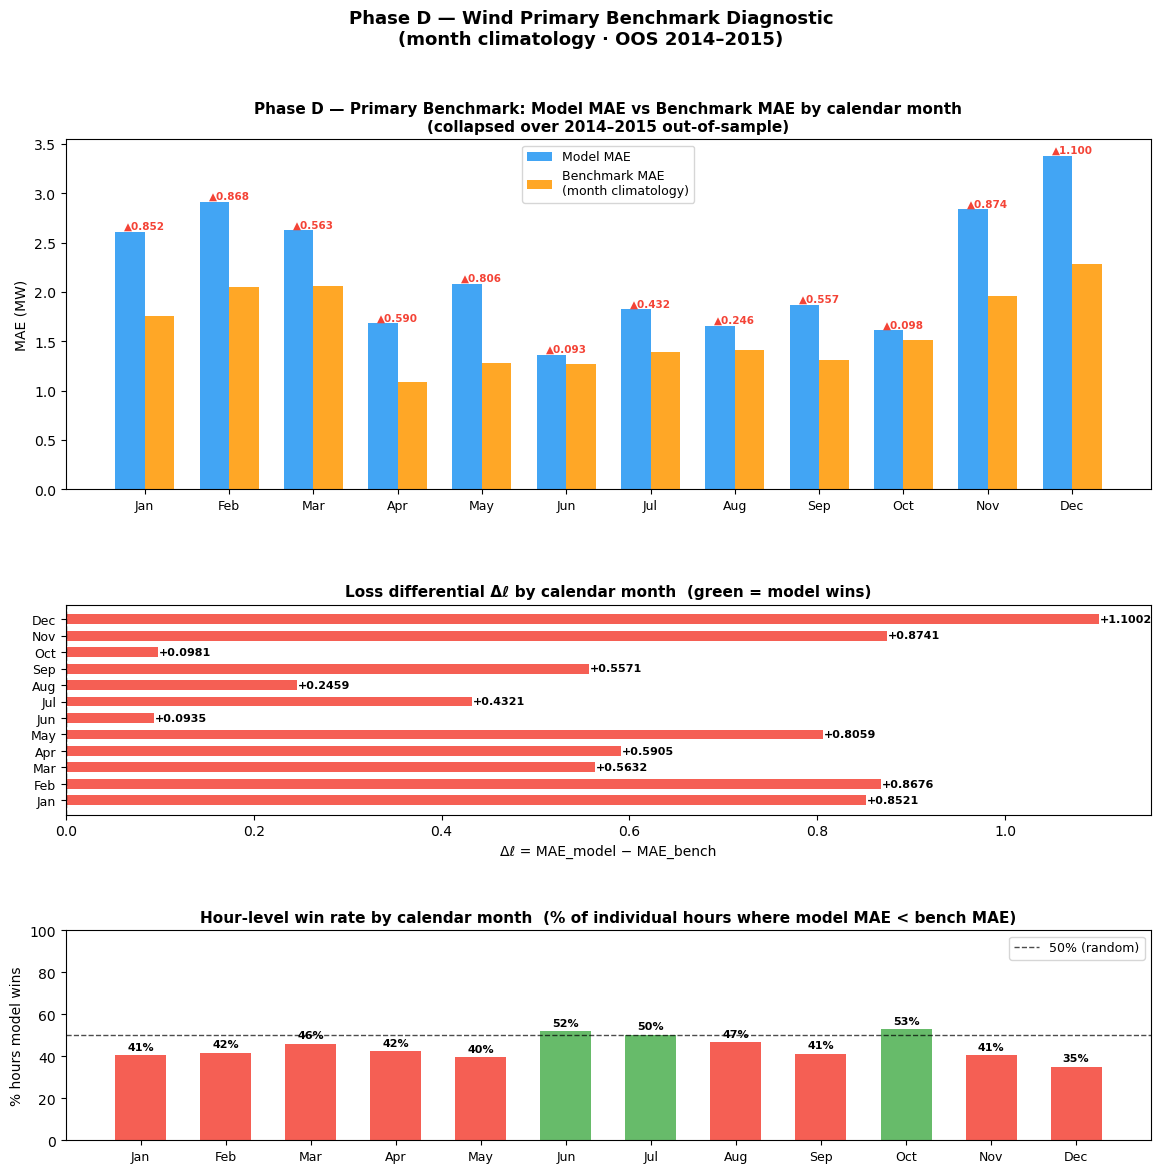

In [ ]:
# =========================================================================
# Phase D.7 — Primary Benchmark: Diagnostics visualization by month (appendix) 
# Benchmark: month climatology — training 2013, OOS 2014-2015
# =========================================================================

# To compute monthly Δℓ, collapsing the two OOS years
wind_oos['delta_l_obs'] = wind_oos['ae_model'] - wind_oos['ae_bench']

# Level 1: monthly (the 24 points of the loss differential path already calculated)
# Level 2: by calendar month (1-12) — collapse 2014 and 2015
cell_loss_primary = wind_oos.groupby('month').agg(
    MAE_model = ('ae_model', 'mean'),
    MAE_bench = ('ae_bench', 'mean'),
    n         = ('ae_model', 'count')
).reset_index()
cell_loss_primary['delta_l']   = cell_loss_primary['MAE_model'] - cell_loss_primary['MAE_bench']
cell_loss_primary['win_rate']  = wind_oos.groupby('month').apply(
    lambda g: (g['delta_l_obs'] < 0).mean() * 100
).values  # % de horas individuales donde el modelo gana

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(3, 1, figsize=(14, 13),
                          gridspec_kw={'height_ratios': [2, 1.2, 1.2], 'hspace': 0.45})

# -----------------------------------------------------------------------
# Panel 1: Grouped bar — monthly MAE_model vs MAE_bench 
# It shows the absolute magnitude of the error for each, not just the difference
# -----------------------------------------------------------------------
x = np.arange(12)
w = 0.35

bars_model = axes[0].bar(x - w/2, cell_loss_primary['MAE_model'], w,
                          label='Model MAE', color='#2196F3', alpha=0.85)
bars_bench = axes[0].bar(x + w/2, cell_loss_primary['MAE_bench'], w,
                          label='Benchmark MAE\n(month climatology)', color='#FF9800', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(month_labels, fontsize=9)
axes[0].set_ylabel('MAE (MW)', fontsize=10)
axes[0].set_title(
    'Phase D — Primary Benchmark: Model MAE vs Benchmark MAE by calendar month\n'
    '(collapsed over 2014–2015 out-of-sample)',
    fontsize=11, fontweight='bold'
)
axes[0].legend(fontsize=9)

# To identify the difference, annotate it above each pair of bars, with color coding (green = model wins, red = benchmark wins)
for i, row in cell_loss_primary.iterrows():
    diff = row['delta_l']
    y_pos = max(row['MAE_model'], row['MAE_bench']) + 0.005
    color = '#4CAF50' if diff < 0 else '#F44336'
    label = f'{"▼" if diff < 0 else "▲"}{abs(diff):.3f}'
    axes[0].text(i, y_pos, label, ha='center', va='bottom',
                 fontsize=7.5, color=color, fontweight='bold')

# -----------------------------------------------------------------------
# Panel 2: monthly Δℓ  — horizontal bar, colored by win/loss
# -----------------------------------------------------------------------
bar_colors = ['#4CAF50' if v < 0 else '#F44336' for v in cell_loss_primary['delta_l']]
axes[1].barh(range(12), cell_loss_primary['delta_l'],
             color=bar_colors, alpha=0.85, height=0.6)
axes[1].axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.8)
axes[1].set_yticks(range(12))
axes[1].set_yticklabels(month_labels, fontsize=9)
axes[1].set_xlabel('Δℓ = MAE_model − MAE_bench', fontsize=10)
axes[1].set_title('Loss differential Δℓ by calendar month  (green = model wins)',
                   fontsize=11, fontweight='bold')

# To identify value in each bar
for i, val in enumerate(cell_loss_primary['delta_l']):
    offset = 0.001 if val >= 0 else -0.001
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset, i, f'{val:+.4f}', va='center', ha=ha,
                 fontsize=8, fontweight='bold')

# -----------------------------------------------------------------------
# Panel 3: %  of individual hours where the model wins, by month
# It commplements aggregated Δℓ — it shows whether the advantage/loss is concentrated
# -----------------------------------------------------------------------
bar_colors_wr = ['#4CAF50' if w >= 50 else '#F44336' for w in cell_loss_primary['win_rate']]
bars_wr = axes[2].bar(range(12), cell_loss_primary['win_rate'],
                       color=bar_colors_wr, alpha=0.85, width=0.6)
axes[2].axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.7, label='50% (random)')
axes[2].set_xticks(range(12))
axes[2].set_xticklabels(month_labels, fontsize=9)
axes[2].set_ylabel('% hours model wins', fontsize=10)
axes[2].set_ylim(0, 100)
axes[2].set_title('Hour-level win rate by calendar month  (% of individual hours where model MAE < bench MAE)',
                   fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

for bar, val in zip(bars_wr, cell_loss_primary['win_rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 1.5,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Phase D — Wind Primary Benchmark Diagnostic\n(month climatology · OOS 2014–2015)',
             fontsize=13, fontweight='bold')
plt.savefig('phase_d_wind_primary_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11472\3278201537.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rate_month = cell_loss.groupby('month').apply(


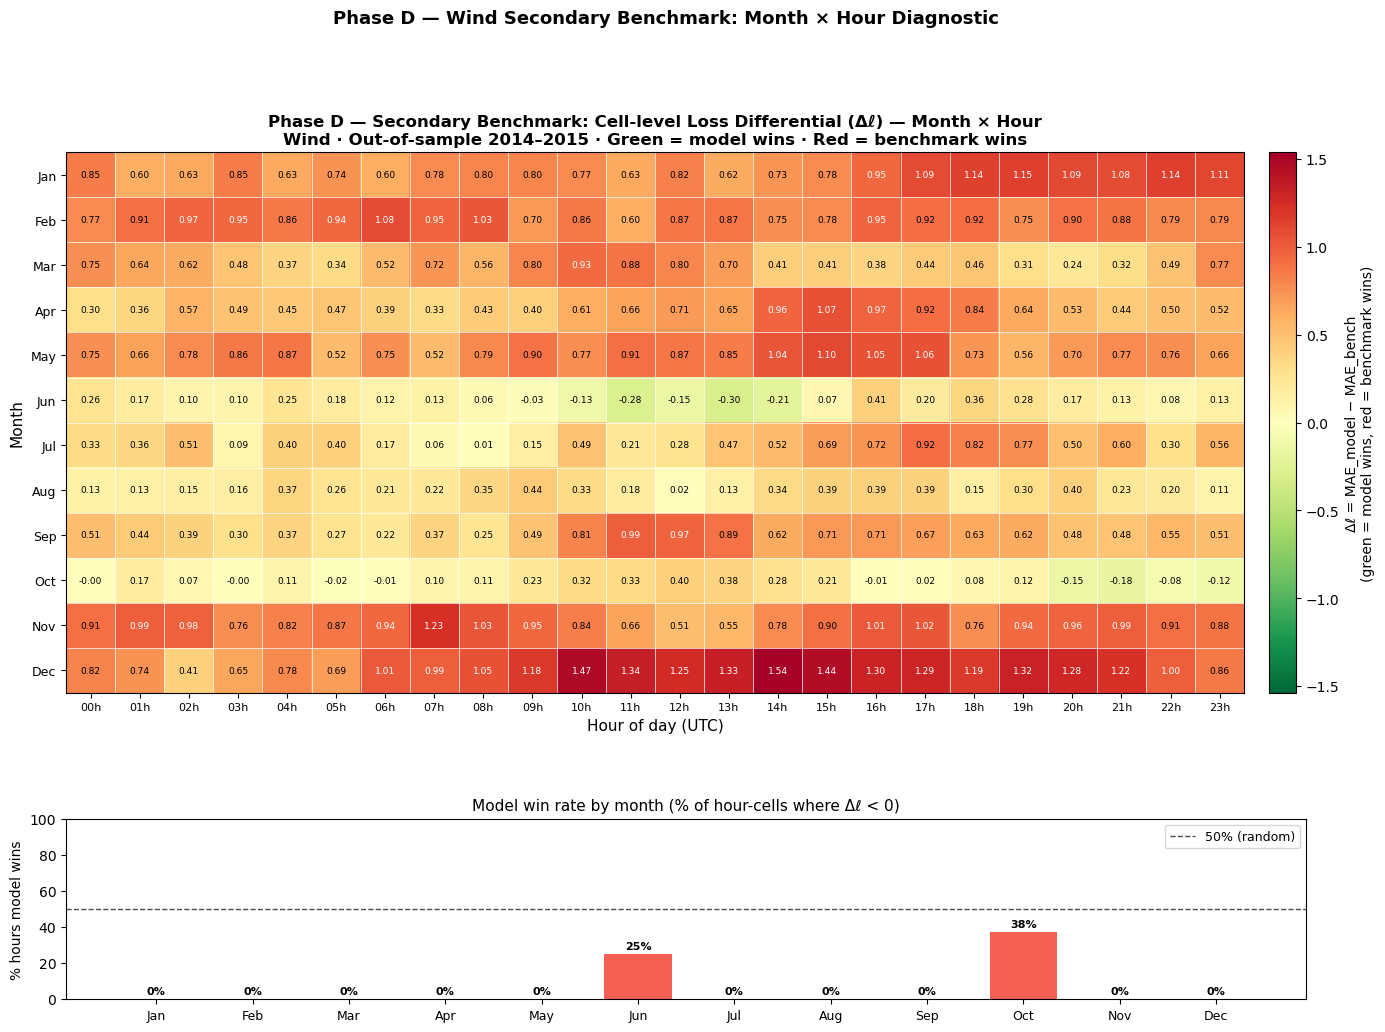

In [ ]:
# =========================================================================
# Phase D.6 — Secondary Benchmark Heatmap: Δℓ per month x hour cell
# =========================================================================

"""To visualize which month×hour cells the model wins/loses against the secondary benchmark, we compute cell-level MAE
 for model and benchmark, then plot the loss differential Δℓ = MAE_model − MAE_bench_sec in a heatmap. Green cells indicate 
 model wins, red cells indicate benchmark wins. It is computed ober 20142015 oos"""

# Calcular MAE del modelo y del benchmark secundario por celda (month, hour)
wind_oos_sec['ae_model']    = (wind_oos_sec['Actuals'] - wind_oos_sec['Simulation']).abs()
wind_oos_sec['ae_bench_sec'] = (wind_oos_sec['Actuals'] - wind_oos_sec['bench_secondary']).abs()

cell_loss = wind_oos_sec.groupby(['month', 'hour']).agg(
    MAE_model    = ('ae_model',     'mean'),
    MAE_bench    = ('ae_bench_sec', 'mean'),
    n            = ('ae_model',     'count')
).reset_index()

cell_loss['delta_l'] = cell_loss['MAE_model'] - cell_loss['MAE_bench']

# Pivot a matriz 12×24
heatmap_data = cell_loss.pivot(index='month', columns='hour', values='delta_l')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# ---- Plot ----
fig, axes = plt.subplots(2, 1, figsize=(16, 11), 
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.35})

# --- Panel 1: Heatmap principal ---
import matplotlib.colors as mcolors

# Escala simétrica alrededor de 0
vmax = np.abs(heatmap_data.values).max()
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = axes[0].imshow(heatmap_data.values, aspect='auto',
                    cmap='RdYlGn_r', norm=norm,
                    interpolation='nearest')

# Colorbar
cbar = fig.colorbar(im, ax=axes[0], fraction=0.03, pad=0.02)
cbar.set_label('Δℓ = MAE_model − MAE_bench\n(green = model wins, red = benchmark wins)',
               fontsize=10)

# Anotaciones en cada celda
for i in range(12):
    for j in range(24):
        val = heatmap_data.values[i, j]
        if np.isnan(val):
            continue
        # Color de texto: blanco si la celda es muy saturada, negro si es clara
        text_color = 'white' if abs(val) > vmax * 0.6 else 'black'
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=6.5, color=text_color, fontweight='normal')

axes[0].set_xticks(range(24))
axes[0].set_xticklabels([f'{h:02d}h' for h in range(24)], fontsize=8)
axes[0].set_yticks(range(12))
axes[0].set_yticklabels(month_labels, fontsize=9)
axes[0].set_xlabel('Hour of day (UTC)', fontsize=11)
axes[0].set_ylabel('Month', fontsize=11)
axes[0].set_title(
    'Phase D — Secondary Benchmark: Cell-level Loss Differential (Δℓ) — Month × Hour\n'
    'Wind · Out-of-sample 2014–2015 · Green = model wins · Red = benchmark wins',
    fontsize=12, fontweight='bold'
)

# Líneas de cuadrícula para separar celdas
axes[0].set_xticks(np.arange(-0.5, 24, 1), minor=True)
axes[0].set_yticks(np.arange(-0.5, 12, 1), minor=True)
axes[0].grid(which='minor', color='white', linewidth=0.5)
axes[0].tick_params(which='minor', bottom=False, left=False)

# --- Panel 2: Win rate por mes (% de horas ganadas por el modelo) ---
win_rate_month = cell_loss.groupby('month').apply(
    lambda g: (g['delta_l'] < 0).mean() * 100
).reset_index()
win_rate_month.columns = ['month', 'win_rate']

bar_colors = ['#4CAF50' if w >= 50 else '#F44336' for w in win_rate_month['win_rate']]
bars = axes[1].bar(range(12), win_rate_month['win_rate'], color=bar_colors, alpha=0.85, width=0.7)
axes[1].axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.7, label='50% (random)')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_labels, fontsize=9)
axes[1].set_ylabel('% hours model wins', fontsize=10)
axes[1].set_ylim(0, 100)
axes[1].set_title('Model win rate by month (% of hour-cells where Δℓ < 0)', fontsize=11)
axes[1].legend(fontsize=9)

# Anotar % en cada barra
for i, (bar, val) in enumerate(zip(bars, win_rate_month['win_rate'])):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1.5,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Phase D — Wind Secondary Benchmark: Month × Hour Diagnostic',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig('phase_d_wind_heatmap_secondary.png', dpi=150, bbox_inches='tight')
plt.show()